# 03 · Feature Engineering
Phase 3: Build Elo ratings from scratch + full match feature matrix.

In [1]:
import sys, os; sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from src.data_loader import load_all, CONFEDERATION_MAP
from src.elo_calculator import build_elo_ratings, EloCalculator
from src.feature_engineer import RollingStatsEngine, build_match_features, build_wc2026_features
np.random.seed(42)
data = load_all(verbose=False)
results_full = data['results_full']
results = data['results_primary']
fixtures = data['group_fixtures']
rankings = data['fifa_rankings']
registry = data['team_registry']


INFO | Loading results from /Users/saurabhgupta/Desktop/ml_projects/fifa-wc-2026-prediction/data/raw/results.csv
INFO |   Raw rows: 49,477
WARNING |   Found 2 duplicate match entries — dropping
INFO |   Full dataset: 49,475 rows | Primary (1990+): 32,358
INFO | former_names.csv columns: ['current', 'former', 'start_date', 'end_date']
INFO | Loaded 42 former name mappings
INFO | Loaded group fixtures: 72 matches, groups ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L']
INFO | Loaded knockout slots: 32 matches
INFO | Loaded FIFA rankings for 48 teams
INFO | Loaded WC historical stats: 964 matches (1930-2022)
INFO | Saved team_registry.csv: 48 teams → /Users/saurabhgupta/Desktop/ml_projects/fifa-wc-2026-prediction/data/processed/team_registry.csv


## 3.1 Build National Team Elo Ratings

In [2]:
print("Computing Elo ratings for all national teams...")
print("Using ALL results from", results_full['date'].min().year, "→", results_full['date'].max().year)

elo_calc, final_elo = build_elo_ratings(
    results_full,
    cutoff_date=pd.Timestamp('2026-06-10'),
    save=True
)

top20 = elo_calc.get_top_n(20)
print("\n📊 Top 20 Teams by Elo Rating (as of June 10, 2026):")
print(top20.to_string(index=False))


INFO | Fitting Elo on 49,475 matches (1872–2026)


Computing Elo ratings for all national teams...
Using ALL results from 1872 → 2026


INFO | Elo fitting complete. Tracked 335 teams.
INFO | VALIDATION: All expected top teams in top-8 Elo ✓
INFO | Extracted 335 team ratings as of 2026-06-10
INFO | Saved final Elo ratings: /Users/saurabhgupta/Desktop/ml_projects/fifa-wc-2026-prediction/data/processed/team_elo_ratings.csv



📊 Top 20 Teams by Elo Rating (as of June 10, 2026):
 rank        team         elo
    1   Argentina 2106.783641
    2      France 2076.172949
    3       Spain 2070.053882
    4    Portugal 1998.886160
    5     Germany 1992.761261
    6      Brazil 1987.178648
    7     England 1970.818240
    8    Colombia 1955.530664
    9 Netherlands 1940.806112
   10       Italy 1906.352641
   11     Belgium 1898.331462
   12 Switzerland 1894.873535
   13       Japan 1889.411804
   14     Morocco 1888.161543
   15      Norway 1882.588160
   16     Austria 1881.726046
   17     Türkiye 1879.966181
   18      Mexico 1874.759380
   19   Australia 1866.822377
   20     Ecuador 1860.045134


## 3.2 Validate Top Teams

Expected top teams in top-8 Elo: {'Spain', 'England', 'Argentina', 'France', 'Brazil'}
Actual top-8 Elo teams: {'Germany', 'Spain', 'Portugal', 'France', 'Brazil', 'Colombia', 'England', 'Argentina'}
✅ Validation passed: All expected top teams in top-8


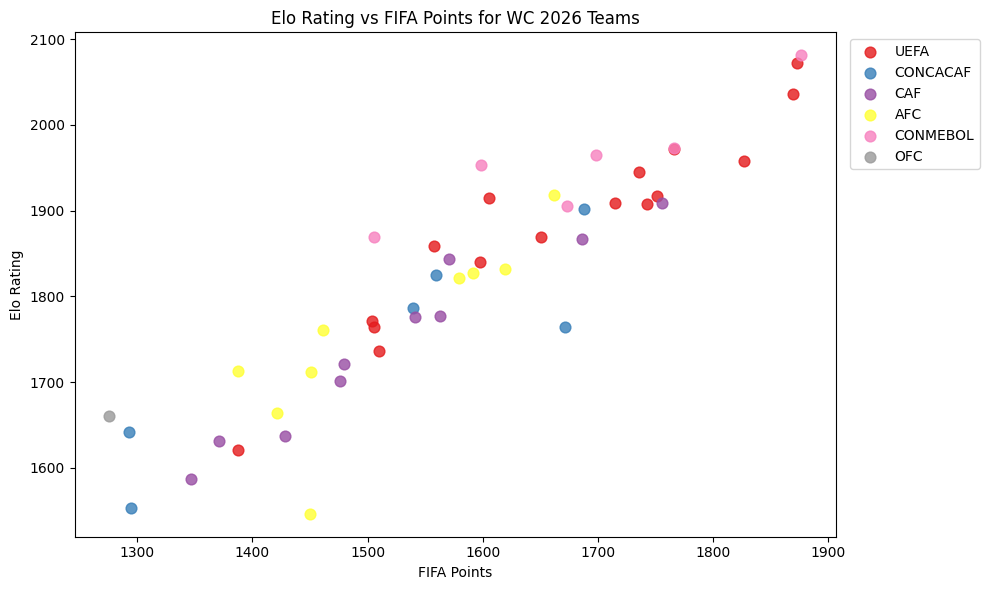


Correlation (Elo vs FIFA Points): 0.922


In [3]:
expected_top = {'France', 'Argentina', 'Brazil', 'Spain', 'England'}
top8_teams = set(top20.head(8)['team'])
print("Expected top teams in top-8 Elo:", expected_top)
print("Actual top-8 Elo teams:", top8_teams)
missing = expected_top - top8_teams
if missing:
    print(f"⚠️  MISSING from top-8: {missing} — check name normalization!")
else:
    print("✅ Validation passed: All expected top teams in top-8")

# Plot Elo vs FIFA ranking for WC teams
wc_elo = []
for _, row in registry.iterrows():
    elo_val = final_elo.get(row['team_name'], 1500)
    wc_elo.append({'team': row['team_name'], 'elo': elo_val,
                   'fifa_rank': row['fifa_ranking'], 'fifa_pts': row['fifa_points'],
                   'confederation': row['confederation']})
wc_elo_df = pd.DataFrame(wc_elo).dropna(subset=['fifa_rank'])

plt.figure(figsize=(10, 6))
confs = wc_elo_df['confederation'].unique()
colors = plt.cm.Set1(np.linspace(0, 1, len(confs)))
for conf, color in zip(confs, colors):
    sub = wc_elo_df[wc_elo_df['confederation'] == conf]
    plt.scatter(sub['fifa_pts'], sub['elo'], label=conf, alpha=0.8, s=60, color=color)
plt.xlabel('FIFA Points'); plt.ylabel('Elo Rating')
plt.title('Elo Rating vs FIFA Points for WC 2026 Teams')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../outputs/plots/elo_vs_fifa.png', dpi=150, bbox_inches='tight')
plt.show()

corr = wc_elo_df[['elo','fifa_pts']].corr().iloc[0,1]
print(f"\nCorrelation (Elo vs FIFA Points): {corr:.3f}")


## 3.3 Build Historical Match Feature Matrix

In [ ]:
# Use 2010+ for training to keep it manageable and reduce noise
print("Building match feature matrix (2010+)...")
print("This processes rolling stats for all teams — may take 5-10 min...")

feat_df = build_match_features(
    results_df=results_full,
    elo_calculator=elo_calc,
    fifa_rankings=rankings,
    confederation_map=CONFEDERATION_MAP,
    min_year=2010,
    save=True
)

print(f"\nFeature matrix shape: {feat_df.shape}")
print("\nOutcome distribution:")
outcome_map = {0: 'Away Win', 1: 'Draw', 2: 'Home Win'}
print(feat_df['outcome'].map(outcome_map).value_counts())
print("\nKey feature stats:")
key_cols = ['elo_diff', 'form_diff_10', 'goals_scored_avg_home', 'goals_conceded_avg_home']
print(feat_df[key_cols].describe().round(3))


INFO | Building features for 15,864 matches (2010+)


Building match feature matrix (2010+)...
This processes rolling stats for all teams — may take 5-10 min...


INFO |   Processing match 0/15,864


## 3.4 Build WC 2026 Feature Matrix

In [ ]:
print("Building WC 2026 feature matrix...")
engine = RollingStatsEngine(results_full)

wc_feat = build_wc2026_features(
    group_fixtures_df=fixtures,
    elo_ratings=final_elo,
    fifa_rankings=rankings,
    confederation_map=CONFEDERATION_MAP,
    rolling_engine=engine,
    cutoff_date=pd.Timestamp('2026-06-10'),
    save=True
)

print(f"WC 2026 features shape: {wc_feat.shape}")
print("\nSample predictions preview:")
preview_cols = ['match_id','group','home_team','away_team','elo_diff','form_diff_10',
                'goals_scored_avg_home','goals_scored_avg_away']
print(wc_feat[preview_cols].head(10).to_string(index=False))


## ✅ Phase 3 Complete
- Elo ratings saved to `data/processed/team_elo_ratings.csv`
- Match features saved to `data/processed/match_features.csv`
- WC 2026 features saved to `data/processed/wc2026_features.csv`